# Health dashboard — all 11 Hub'Eau APIs

Uses `check_health()` from [`hubeau-data`](https://pypi.org/project/hubeau-data/) to probe
every Hub'Eau API endpoint and summarise availability and latency.

All checks run sequentially (one HTTP round-trip per endpoint × 3 repetitions).
A `healthy_ratio` of 1.0 means every endpoint responded successfully.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from hubeau_data.client import HubeauClient

client = HubeauClient()

## Run health checks

Each API exposes a `check_health()` method that probes its endpoints 3 times
and returns a `HealthReport` with per-endpoint latency stats.

In [2]:
apis = {
    "hydrometrie":           client.hydrometrie,
    "qualite_rivieres":      client.qualite_rivieres,
    "piezometrie":           client.piezometrie,
    "qualite_nappes":        client.qualite_nappes,
    "ecoulement":            client.ecoulement,
    "temperature":           client.temperature,
    "prelevements":          client.prelevements,
    "hydrobiologie":         client.hydrobiologie,
    "poisson":               client.poisson,
    "eau_potable":           client.eau_potable,
    "phytopharmaceutiques":  client.phytopharmaceutiques,
}

reports = {}
for name, api in apis.items():
    print(f"  checking {name}...", end=" ", flush=True)
    reports[name] = api.check_health()
    ratio = reports[name].healthy_ratio
    print("✓" if ratio == 1.0 else f"⚠ {ratio:.0%}")

  checking hydrometrie... ✓
  checking qualite_rivieres... ⚠ 25%
  checking piezometrie... ✓
  checking qualite_nappes... ✓
  checking ecoulement... ✓
  checking temperature... ✓
  checking prelevements... ✓
  checking hydrobiologie... ✓
  checking poisson... ✓
  checking eau_potable... ✓
  checking phytopharmaceutiques... ✓


## Summary table

In [3]:
rows = []
for name, report in reports.items():
    for ep in report.endpoints:
        rows.append({
            "api":          name,
            "endpoint":     ep.name,
            "ok":           ep.ok,
            "latency_avg":  ep.latency_ms_avg,
            "latency_min":  ep.latency_ms_min,
            "latency_max":  ep.latency_ms_max,
            "error":        ep.error,
        })

df = pd.DataFrame(rows)
df

,api,endpoint,ok,latency_avg,latency_min,latency_max,error
0,hydrometrie,referentiel/sites,True,82.9,58.1,129.4,NaN
1,hydrometrie,referentiel/stations,True,64.3,62.3,65.8,NaN
2,hydrometrie,observations_tr,True,423.0,406.3,439.0,NaN
3,hydrometrie,obs_elab,True,2800.0,2599.7,3129.0,NaN
4,qualite_rivieres,station_pc,False,NaN,NaN,NaN,ReadTimeout
5,qualite_rivieres,analyse_pc,True,66.0,63.8,69.1,NaN
6,qualite_rivieres,operation_pc,False,NaN,NaN,NaN,ReadTimeout
7,qualite_rivieres,condition_environnementale_pc,False,NaN,NaN,NaN,ReadTimeout
8,piezometrie,stations,True,59.9,57.7,62.9,NaN
9,piezometrie,chroniques,True,625.8,65.4,1260.4,NaN


## Latency heatmap

Average response time per endpoint. Green = fast, red = slow. Grey = endpoint down.

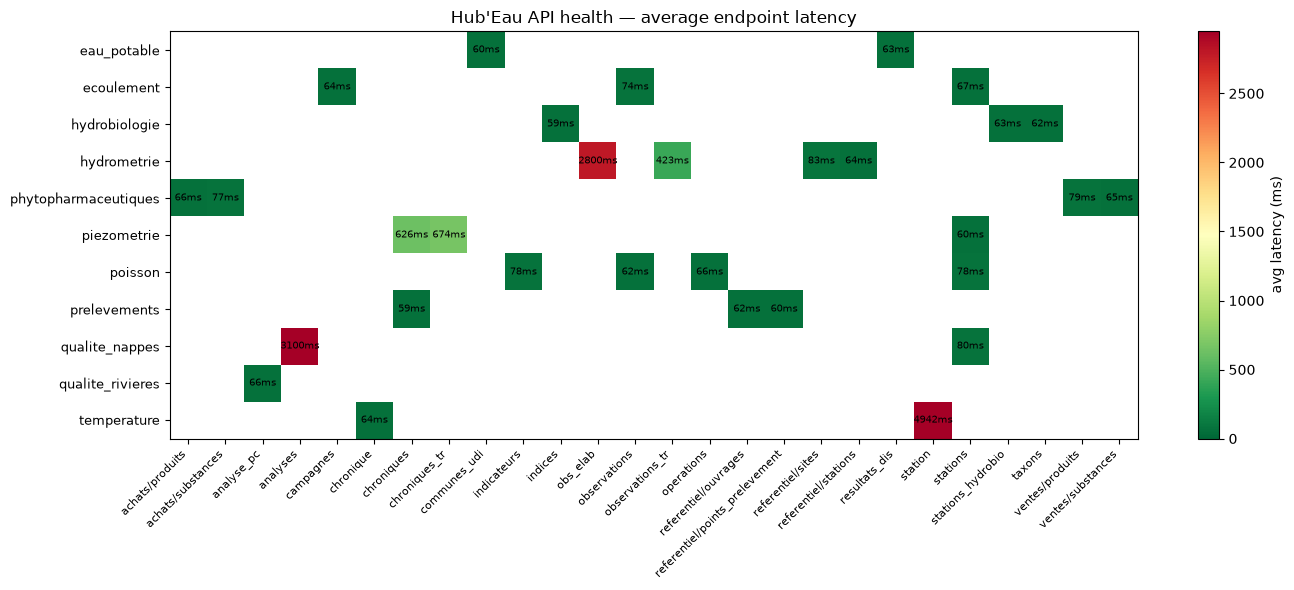

In [4]:
pivot = df[df["ok"]].pivot(index="api", columns="endpoint", values="latency_avg")

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r",
               vmin=0, vmax=df["latency_avg"].quantile(0.95))

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.0f}ms", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="avg latency (ms)")
ax.set_title("Hub'Eau API health — average endpoint latency")
plt.tight_layout()
plt.show()

## Per-API healthy ratio

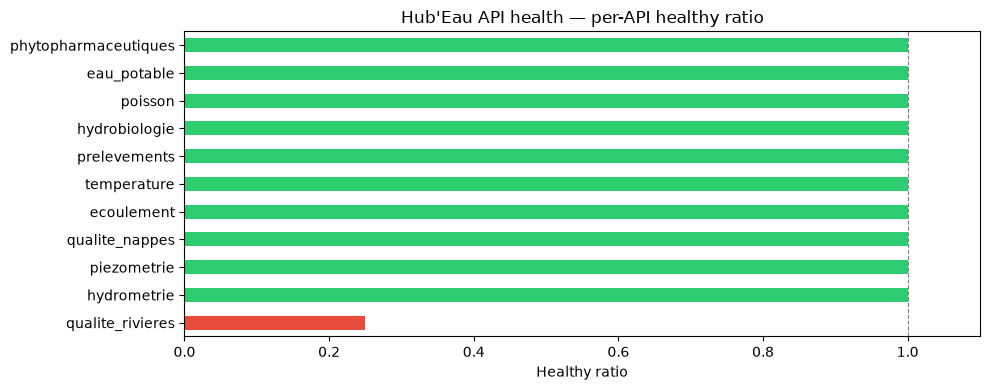

In [5]:
ratios = pd.Series(
    {name: report.healthy_ratio for name, report in reports.items()}
).sort_values()

colors = ["#2ecc71" if r == 1.0 else "#e74c3c" for r in ratios]

fig, ax = plt.subplots(figsize=(10, 4))
ratios.plot(kind="barh", ax=ax, color=colors)
ax.set_xlim(0, 1.1)
ax.set_xlabel("Healthy ratio")
ax.set_title("Hub'Eau API health — per-API healthy ratio")
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()